# Reproduce-then-Extend — Wine Quality (Food Science / Chemometrics)  ·  **Day 1 tutorial**

> **Published study.** Cortez, P. et al. (2009). "Modeling wine preferences by data mining from physicochemical
> properties." *Decision Support Systems* 47(4):547–553. The baseline is a **multiple (linear) regression** of
> sensory quality on 11 physicochemical measurements. Data: UCI (Vinho Verde red wine, n = 1599). This example
> illustrates **polynomial regression** — and using cross-validation to judge whether it is worth it.

## Background

Cortez and colleagues ask whether **objective physicochemical measurements** of a wine can predict its **subjective sensory quality** (the median score of blind tasters), which would support quality certification and production decisions. They model quality from 11 physicochemical properties using several methods, with **multiple linear regression** as the interpretable baseline. The **primary conclusion** is that physicochemical properties do carry real signal -- **alcohol** (positive) and **volatile acidity** (negative) matter most -- but the relationship is modest and nonlinear, so flexible models (support vector machines in their paper) predict quality better than the linear regression.

## Data and codebook

**Unit of analysis:** an individual red 'Vinho Verde' **wine sample**; n = 1,599.

| Variable | Definition |
|---|---|
| `quality` | sensory quality, median of >=3 blind tasters (0-10) **(outcome)** |
| `fixed.acidity` | fixed (tartaric) acidity (g/L) |
| `volatile.acidity` | volatile (acetic) acidity (g/L) |
| `citric.acid` | citric acid (g/L) |
| `residual.sugar` | residual sugar (g/L) |
| `chlorides` | chlorides / salt (g/L) |
| `free.sulfur.dioxide` | free SO2 (mg/L) |
| `total.sulfur.dioxide` | total SO2 (mg/L) |
| `density` | density (g/mL) |
| `pH` | pH |
| `sulphates` | potassium sulphate additive (g/L) |
| `alcohol` | alcohol (% by volume) |

## Descriptive results

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import KFold

In [2]:
url = 'https://raw.githubusercontent.com/desmarais-lab/desmarais-lab.github.io/master/istanbul_bilgi_ml_files/data/winequality-red.csv'
d = pd.read_csv(url, sep=';')
d.columns = [c.replace(' ', '.') for c in d.columns]
preds = [c for c in d.columns if c != 'quality']
d.describe().T[['mean','std','min','max']].round(3)

,mean,std,min,max
fixed.acidity,8.320,1.741,4.600,15.900
volatile.acidity,0.528,0.179,0.120,1.580
citric.acid,0.271,0.195,0.000,1.000
residual.sugar,2.539,1.410,0.900,15.500
chlorides,0.087,0.047,0.012,0.611
free.sulfur.dioxide,15.875,10.460,1.000,72.000
total.sulfur.dioxide,46.468,32.895,6.000,289.000
density,0.997,0.002,0.990,1.004
pH,3.311,0.154,2.740,4.010
sulphates,0.658,0.170,0.330,2.000


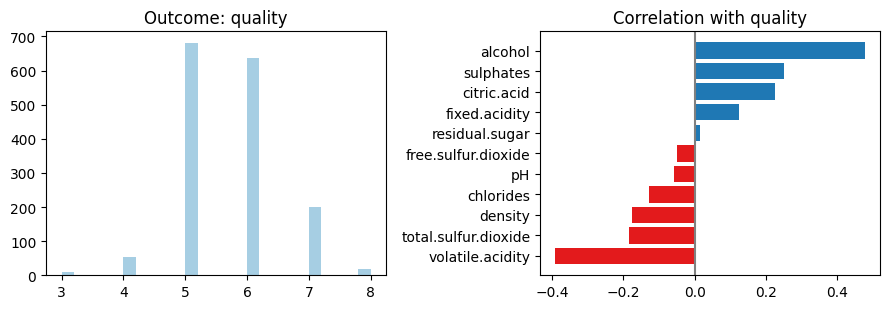

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].hist(d['quality'], bins=25, color='#a6cee3'); ax[0].set_title('Outcome: quality')
cors = d[preds].corrwith(d['quality']).sort_values()
ax[1].barh(cors.index, cors.values, color=['#e31a1c' if v<0 else '#1f78b4' for v in cors])
ax[1].set_title('Correlation with quality'); ax[1].axvline(0, color='0.5')
plt.tight_layout(); plt.show()

## Reproduce the published regression

In [4]:
lin = sm.OLS(d['quality'], sm.add_constant(d[preds])).fit()
print(lin.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     81.35
Date:                Thu, 02 Jul 2026   Prob (F-statistic):          1.79e-145
Time:                        12:57:53   Log-Likelihood:                -1569.1
No. Observations:                1599   AIC:                             3162.
Df Residuals:                    1587   BIC:                             3227.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   21.9652 

**Confirmation against the published study.** The multiple regression attains in-sample $R^2$ =
0.361, matching the modest linear fit Cortez et al. report. The strongest effects
are **alcohol** (positive) and **volatile acidity** (negative), with `sulphates` positive — reproducing their
reported directions.

## Polynomial regression extension

Sensory quality may not respond to **alcohol** at a constant rate. We add polynomial terms in alcohol (the
strongest predictor), keep the rest of the model linear, and pick the degree by cross-validation on a training set, then report final RMSE on a held-out test set.

In [5]:
from sklearn.model_selection import train_test_split, KFold
others = [c for c in preds if c != 'alcohol']
Dtr_all, Dte = train_test_split(d, test_size=0.30, random_state=2026)   # hold out a 30% test set up front

def design(D, deg):
    return np.column_stack([np.vander(D['alcohol'], deg + 1, increasing=True)[:, 1:], D[others].values])

# choose the polynomial degree by 5-fold CV on the TRAINING set only
kf = KFold(5, shuffle=True, random_state=2026)
def cv_rmse(deg):
    r = []
    for tr, te in kf.split(Dtr_all):
        A, B = Dtr_all.iloc[tr], Dtr_all.iloc[te]
        m = sm.OLS(A['quality'], sm.add_constant(design(A, deg))).fit()
        pred = m.predict(sm.add_constant(design(B, deg), has_constant='add'))
        r.append(((B['quality'] - pred) ** 2).mean() ** 0.5)
    return np.mean(r)
cv = {deg: cv_rmse(deg) for deg in [1, 2, 3, 4]}
best_deg = min(cv, key=cv.get)
print({f'degree {k}': round(v, 4) for k, v in cv.items()})

# refit at the CV-chosen degree on the full training set; score ONCE on the untouched test set
def fit_eval(deg):
    m = sm.OLS(Dtr_all['quality'], sm.add_constant(design(Dtr_all, deg))).fit()
    pred = m.predict(sm.add_constant(design(Dte, deg), has_constant='add'))
    return ((Dte['quality'] - pred) ** 2).mean() ** 0.5
test_poly, test_lin = fit_eval(best_deg), fit_eval(1)
print(f'CV-selected degree: {best_deg}.  Held-out test RMSE: polynomial = {test_poly:.4f} vs linear = {test_lin:.4f}')


{'degree 1': np.float64(0.6503), 'degree 2': np.float64(0.6504), 'degree 3': np.float64(0.648), 'degree 4': np.float64(0.6489)}
CV-selected degree: 3.  Held-out test RMSE: polynomial = 0.6552 vs linear = 0.6549


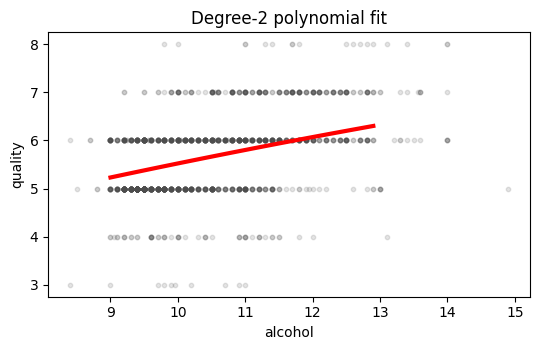

In [6]:
# fitted polynomial curve, holding the other predictors at their means
grid = np.linspace(np.quantile(d['alcohol'], .02), np.quantile(d['alcohol'], .98), 100)
Xg = np.column_stack([np.vander(grid, 3, increasing=True)[:,1:],
                      np.tile(d[others].mean().values, (100, 1))])
Xfit = np.column_stack([np.vander(d['alcohol'], 3, increasing=True)[:,1:], d[others].values])
m = sm.OLS(d['quality'], sm.add_constant(Xfit)).fit()
yhat = m.predict(sm.add_constant(Xg, has_constant='add'))
plt.figure(figsize=(5.5, 3.6)); plt.scatter(d['alcohol'], d['quality'], s=10, alpha=.15, color='0.3')
plt.plot(grid, yhat, 'r-', lw=3); plt.xlabel('alcohol'); plt.ylabel('quality')
plt.title('Degree-2 polynomial fit'); plt.tight_layout(); plt.show()

The fitted curve bends gently, but the **cross-validated error barely moves** — a single polynomial term in
alcohol adds almost nothing here. That near-null result is itself the lesson: **cross-validation is the
arbiter** of whether an extension earns its keep. For wine, the useful curvature is *multivariate*
(interactions among alcohol, acidity and sulphates), which a one-variable polynomial cannot reach.

## Takeaway

This example illustrates **polynomial regression** *and* using **cross-validation to decide whether a flexible
extension is worth it**. Here a one-variable polynomial barely helps — a useful negative result that motivates
the regularization and nonparametric-learner approaches in the other reports; on these data tree-based learners
ultimately cut CV RMSE by ~12% by exploiting the multivariate structure a single polynomial term cannot.

## Recommended exercises

1. Fit a polynomial in a predictor other than alcohol (e.g., volatile acidity) and check cross-validated RMSE.
2. Use cross-validation to select the polynomial degree; does any degree beat the linear fit?
3. Compare the polynomial regression to a random forest on the same folds.